In [1]:
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

CLEAN_PATH    = "processed/floodsense_clean.csv"
ENG_PATH      = "processed/floodsense_engineered.csv"
PLOTS_DIR     = "engineered_plots"
MODELS_DIR    = "engineered_models"
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

LEAN_BASELINE_AUC = 0.5451
FULL_BASELINE_AUC = 0.8518

def section(title):
    print("\n" + "=" * 75 + f"\n{title}\n" + "=" * 75)

In [2]:
df = pd.read_csv(CLEAN_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["district", "date"]).reset_index(drop=True)
print(f"Loaded cleaned data: {df.shape}")
n_orig_features = df.shape[1]
df.head()

Loaded cleaned data: (1365, 23)


,date,evaporation,precipitation,pressure,soil_moisture,temperature,water_area_km2,wind_speed,humidity,precip_3day_avg,...,day_of_year,month,year,is_monsoon,water_area_change,water_area_pct_change,flood_event,district,avg_elevation_m,is_missing_precipitation
0,2023-01-01,-0.000230,0.000135,100639.5491,0.087776,16.712126,73.521606,0.625041,50.787158,0.000159,...,1.0,1,2023,0,-178.235539,-0.707966,0,Balochistan_District,610,0
1,2023-01-01,-0.000230,NaN,100639.5491,0.087776,16.712126,374.708945,0.625041,50.787158,0.000204,...,1.0,1,2023,0,301.187339,4.096583,0,Balochistan_District,610,1
2,2023-01-02,-0.000215,0.000000,100800.0680,0.087691,16.070381,250.390562,2.556115,54.975463,0.000090,...,2.0,1,2023,0,-124.318384,-0.331773,0,Balochistan_District,610,0
3,2023-01-03,-0.000217,0.000000,101029.1779,0.087694,15.405261,126.072178,2.904837,49.248183,0.000045,...,3.0,1,2023,0,-124.318384,-0.496498,0,Balochistan_District,610,0
4,2023-01-04,-0.000214,0.000000,101026.6490,0.087631,14.635752,1.753794,2.287333,51.012060,0.000000,...,4.0,1,2023,0,-124.318384,-0.986089,0,Balochistan_District,610,0


In [3]:
section("CATEGORY 1 — Lag features")

lag_specs = [
    ("precipitation",  [1, 2, 3, 5, 7]),
    ("soil_moisture",  [1, 2, 3]),
    ("water_area_km2", [1, 2, 3]),
    ("humidity",       [1, 2]),
    ("pressure",       [1]),
]

for col, lags in lag_specs:
    for lag in lags:
        new_col = f"{col}_lag{lag}"
        df[new_col] = df.groupby("district")[col].shift(lag)
        print(f"  Created {new_col}")

lag_features_added = sum(len(lags) for _, lags in lag_specs)
print(f"\nTotal lag features added: {lag_features_added}")


CATEGORY 1 — Lag features
  Created precipitation_lag1
  Created precipitation_lag2
  Created precipitation_lag3
  Created precipitation_lag5
  Created precipitation_lag7
  Created soil_moisture_lag1
  Created soil_moisture_lag2
  Created soil_moisture_lag3
  Created water_area_km2_lag1
  Created water_area_km2_lag2
  Created water_area_km2_lag3
  Created humidity_lag1
  Created humidity_lag2
  Created pressure_lag1

Total lag features added: 14


In [4]:
section("CATEGORY 2 — Rolling features (recomputed within district)")

for w in [3, 7, 14, 30]:
    new_col = f"precipitation_{w}day_sum"
    df[new_col] = df.groupby("district")["precipitation"].transform(
        lambda x: x.rolling(w, min_periods=1).sum())
    print(f"  Created {new_col}")

df["soil_moisture_7day_avg"] = df.groupby("district")["soil_moisture"].transform(
    lambda x: x.rolling(7, min_periods=1).mean())
print(f"  Created soil_moisture_7day_avg")

df["temperature_7day_avg"] = df.groupby("district")["temperature"].transform(
    lambda x: x.rolling(7, min_periods=1).mean())
print(f"  Created temperature_7day_avg")


CATEGORY 2 — Rolling features (recomputed within district)
  Created precipitation_3day_sum
  Created precipitation_7day_sum
  Created precipitation_14day_sum
  Created precipitation_30day_sum
  Created soil_moisture_7day_avg
  Created temperature_7day_avg


In [5]:
section("CATEGORY 3 — Rate-of-change features")

df["precip_change_1day"]       = df.groupby("district")["precipitation"].diff(1)
df["soil_moisture_change_3day"] = df.groupby("district")["soil_moisture"].diff(3)
df["pressure_drop_1day"]       = -df.groupby("district")["pressure"].diff(1)
print("  Created precip_change_1day, soil_moisture_change_3day, pressure_drop_1day")


CATEGORY 3 — Rate-of-change features
  Created precip_change_1day, soil_moisture_change_3day, pressure_drop_1day


In [6]:
section("CATEGORY 4 — District anomaly z-scores")

zscore_targets = ["precipitation", "soil_moisture", "temperature", "pressure",
                  "water_area_km2_lag1", "water_area_km2_lag2", "water_area_km2_lag3"]

for col in zscore_targets:
    district_mean = df.groupby("district")[col].transform("mean")
    district_std  = df.groupby("district")[col].transform("std")
    df[f"{col}_zscore"] = (df[col] - district_mean) / district_std
    print(f"  Created {col}_zscore")


CATEGORY 4 — District anomaly z-scores
  Created precipitation_zscore
  Created soil_moisture_zscore
  Created temperature_zscore
  Created pressure_zscore
  Created water_area_km2_lag1_zscore
  Created water_area_km2_lag2_zscore
  Created water_area_km2_lag3_zscore


In [7]:
section("CATEGORY 5 — Time-since-event features")

df["_heavy_rain_date"] = df["date"].where(df["precipitation"] > 20)
df["_last_heavy_rain"] = df.groupby("district")["_heavy_rain_date"].ffill()
df["days_since_heavy_rain"] = (df["date"] - df["_last_heavy_rain"]).dt.days
df = df.drop(columns=["_heavy_rain_date", "_last_heavy_rain"])
print("  Created days_since_heavy_rain")

df["_dry_date"] = df["date"].where(df["precipitation"] < 1)
df["_last_dry"] = df.groupby("district")["_dry_date"].ffill()
df["days_since_dry_day"] = (df["date"] - df["_last_dry"]).dt.days
df = df.drop(columns=["_dry_date", "_last_dry"])
print("  Created days_since_dry_day")

def days_since_monsoon_start(d):
    if 6 <= d.month <= 9:
        return (d - pd.Timestamp(f"{d.year}-06-01")).days
    return 0

df["days_in_monsoon"] = df["date"].apply(days_since_monsoon_start)
print("  Created days_in_monsoon")


CATEGORY 5 — Time-since-event features
  Created days_since_heavy_rain
  Created days_since_dry_day
  Created days_in_monsoon


In [8]:
section("CATEGORY 6 — Interaction features")

df["precip_x_soil_moisture"]      = df["precipitation"] * df["soil_moisture"]
df["precip_7day_x_monsoon"]       = df["precipitation_7day_sum"] * df["is_monsoon"]
df["pressure_low_x_humidity_high"] = (100000 - df["pressure"]).clip(lower=0) * df["humidity"] / 100
print("  Created precip_x_soil_moisture, precip_7day_x_monsoon, pressure_low_x_humidity_high")


CATEGORY 6 — Interaction features
  Created precip_x_soil_moisture, precip_7day_x_monsoon, pressure_low_x_humidity_high


In [9]:
section("DROPPING REDUNDANT FEATURES (conservative)")

to_drop = [
    "water_area_km2",
    "water_area_change",
    "water_area_pct_change",
    "precip_3day_avg",
    "precip_7day_avg",
    "soil_3day_avg",
    "temp_3day_avg",
    "day_of_year",
    "year",
]

dropped = [c for c in to_drop if c in df.columns]
df = df.drop(columns=dropped)
print(f"Dropped {len(dropped)} columns: {dropped}")


DROPPING REDUNDANT FEATURES (conservative)
Dropped 9 columns: ['water_area_km2', 'water_area_change', 'water_area_pct_change', 'precip_3day_avg', 'precip_7day_avg', 'soil_3day_avg', 'temp_3day_avg', 'day_of_year', 'year']


In [10]:
section("ENGINEERED DATASET SUMMARY")

print(f"Started with: {n_orig_features} columns")
print(f"Now have:     {df.shape[1]} columns")
print(f"Net features added: {df.shape[1] - n_orig_features + len(dropped)}")

non_meta = [c for c in df.columns if c not in ["date", "district", "flood_event"]]
print(f"\nFinal feature columns: ({len(non_meta)} feature columns + date, district, flood_event)")

df.to_csv(ENG_PATH, index=False)
print(f"\nSaved engineered dataset → {ENG_PATH}")


ENGINEERED DATASET SUMMARY
Started with: 23 columns
Now have:     50 columns
Net features added: 36

Final feature columns: (47 feature columns + date, district, flood_event)

Saved engineered dataset → processed/floodsense_engineered.csv


In [11]:
section("RE-RUNNING CV WITH ENGINEERED FEATURES")

target = "flood_event"
exclude = ["date", target, "district"]
feature_cols = [c for c in df.columns if c not in exclude]
print(f"Using {len(feature_cols)} features for modeling")

X = df[feature_cols].copy()
y = df[target].values
groups = df["district"]
X = X.replace([np.inf, -np.inf], np.nan)

gkf = GroupKFold(n_splits=3)
params = {
    "objective":         "binary",
    "metric":            "auc",
    "learning_rate":     0.05,
    "num_leaves":        31,
    "min_data_in_leaf":  20,
    "feature_fraction":  0.9,
    "bagging_fraction":  0.8,
    "bagging_freq":      5,
    "is_unbalance":      True,
    "verbose":           -1,
    "random_state":      42,
}


RE-RUNNING CV WITH ENGINEERED FEATURES
Using 47 features for modeling


In [12]:
oof_preds   = np.zeros(len(df))
fold_aucs, fold_districts, fold_imp, models = [], [], [], []

for fold, (tr_idx, vl_idx) in enumerate(gkf.split(X, y, groups), start=1):
    X_tr, X_vl = X.iloc[tr_idx], X.iloc[vl_idx]
    y_tr, y_vl = y[tr_idx], y[vl_idx]
    held_out = df.iloc[vl_idx]["district"].iloc[0]
    fold_districts.append(held_out)

    train_data = lgb.Dataset(X_tr, label=y_tr)
    val_data   = lgb.Dataset(X_vl, label=y_vl, reference=train_data)

    model = lgb.train(
        params, train_data,
        num_boost_round=2000,
        valid_sets=[val_data], valid_names=["val"],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)],
    )

    val_preds = model.predict(X_vl, num_iteration=model.best_iteration)
    oof_preds[vl_idx] = val_preds

    fold_auc = roc_auc_score(y_vl, val_preds)
    fold_aucs.append(fold_auc)
    fold_imp.append(model.feature_importance(importance_type="gain"))
    models.append(model)

    print(f"  Fold {fold} (held-out: {held_out:25s}): AUC = {fold_auc:.4f}  "
          f"(best iter = {model.best_iteration})")

overall_auc = roc_auc_score(y, oof_preds)
oof_bin = (oof_preds >= 0.5).astype(int)
acc  = accuracy_score(y, oof_bin)
prec = precision_score(y, oof_bin)
rec  = recall_score(y, oof_bin)
f1   = f1_score(y, oof_bin)
cm   = confusion_matrix(y, oof_bin)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[15]	val's auc: 0.96335
  Fold 1 (held-out: Sindh_District           ): AUC = 0.9633  (best iter = 15)
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[65]	val's auc: 0.981412
  Fold 2 (held-out: Balochistan_District     ): AUC = 0.9814  (best iter = 65)
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[45]	val's auc: 0.96904
  Fold 3 (held-out: KP_District              ): AUC = 0.9690  (best iter = 45)


In [13]:
section("COMPARISON — engineered vs baselines")

cmp = pd.DataFrame({
    "Variant":            ["Lean baseline (no engineering)",
                           "FE model (engineered)",
                           "Full baseline (with leak)"],
    "Cross-district AUC": [LEAN_BASELINE_AUC, overall_auc, FULL_BASELINE_AUC],
    "Defensible?":        ["yes (low signal)",
                           "yes (legitimate features)",
                           "no (uses leak)"],
})
cmp["Cross-district AUC"] = cmp["Cross-district AUC"].round(4)
print(cmp.to_string(index=False))

print(f"\nImprovement over lean baseline: +{overall_auc - LEAN_BASELINE_AUC:.4f}")
print(f"\n--- Engineered model details ---")
print(f"Cross-district AUC:  {overall_auc:.4f}  (mean per-fold {np.mean(fold_aucs):.4f}, std {np.std(fold_aucs):.4f})")
print(f"Accuracy @ 0.5:      {acc:.4f}  (brief threshold > 0.70: {'PASS' if acc > 0.70 else 'FAIL'})")
print(f"Precision:           {prec:.4f}")
print(f"Recall:              {rec:.4f}")
print(f"F1:                  {f1:.4f}")
print(f"\nConfusion matrix:")
print(f"                Predicted 0   Predicted 1")
print(f"  Actual 0:        {cm[0,0]:>5d}        {cm[0,1]:>5d}")
print(f"  Actual 1:        {cm[1,0]:>5d}        {cm[1,1]:>5d}")
print(f"\nPer-district held-out AUC:")
for d, a in zip(fold_districts, fold_aucs):
    print(f"  {d:25s}  {a:.4f}")


COMPARISON — engineered vs baselines
                       Variant  Cross-district AUC               Defensible?
Lean baseline (no engineering)              0.5451          yes (low signal)
         FE model (engineered)              0.9560 yes (legitimate features)
     Full baseline (with leak)              0.8518            no (uses leak)

Improvement over lean baseline: +0.4109

--- Engineered model details ---
Cross-district AUC:  0.9560  (mean per-fold 0.9713, std 0.0075)
Accuracy @ 0.5:      0.9092  (brief threshold > 0.70: PASS)
Precision:           0.8518
Recall:              0.8710
F1:                  0.8613

Confusion matrix:
                Predicted 0   Predicted 1
  Actual 0:          856           67
  Actual 1:           57          385

Per-district held-out AUC:
  Sindh_District             0.9633
  Balochistan_District       0.9814
  KP_District                0.9690


In [14]:
section("FEATURE IMPORTANCE — top 20 (averaged across 3 folds)")

importance_df = pd.DataFrame({
    "feature":    feature_cols,
    "importance": np.mean(fold_imp, axis=0),
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(importance_df.head(20).to_string(index=False))


FEATURE IMPORTANCE — top 20 (averaged across 3 folds)
                   feature  importance
water_area_km2_lag1_zscore 2582.733265
       water_area_km2_lag1 2429.725527
       water_area_km2_lag3 1414.539736
       water_area_km2_lag2 1303.820761
water_area_km2_lag2_zscore  793.828321
water_area_km2_lag3_zscore  564.619489
        pressure_drop_1day  124.516007
      temperature_7day_avg   66.312937
 soil_moisture_change_3day   59.394273
        precipitation_lag7   59.249324
                wind_speed   55.232149
             pressure_lag1   51.503360
        precipitation_lag3   43.356591
      precipitation_zscore   35.819828
             humidity_lag1   31.784375
        temperature_zscore   30.819767
        precip_change_1day   30.038397
        precipitation_lag2   29.694497
               evaporation   26.084644
                     month   24.107837


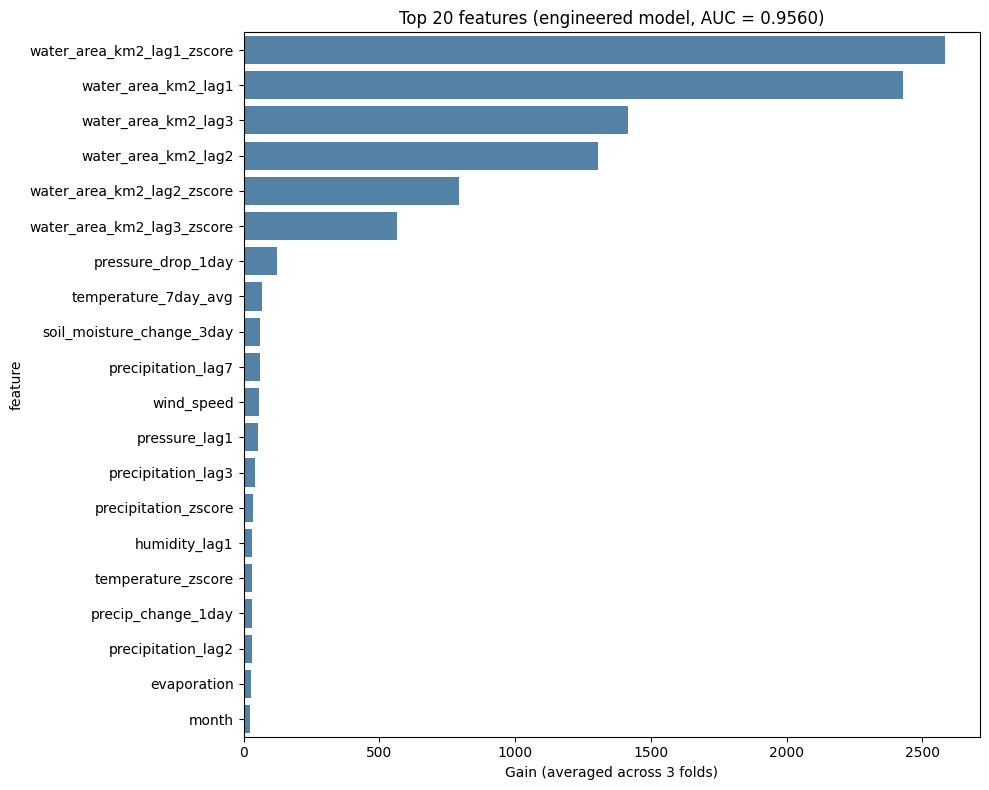

In [15]:
plt.figure(figsize=(10, 8))
top20 = importance_df.head(20)
sns.barplot(data=top20, x="importance", y="feature", color="steelblue")
plt.title(f"Top 20 features (engineered model, AUC = {overall_auc:.4f})")
plt.xlabel("Gain (averaged across 3 folds)")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/feature_importance.png", dpi=80)
plt.show()
plt.close()

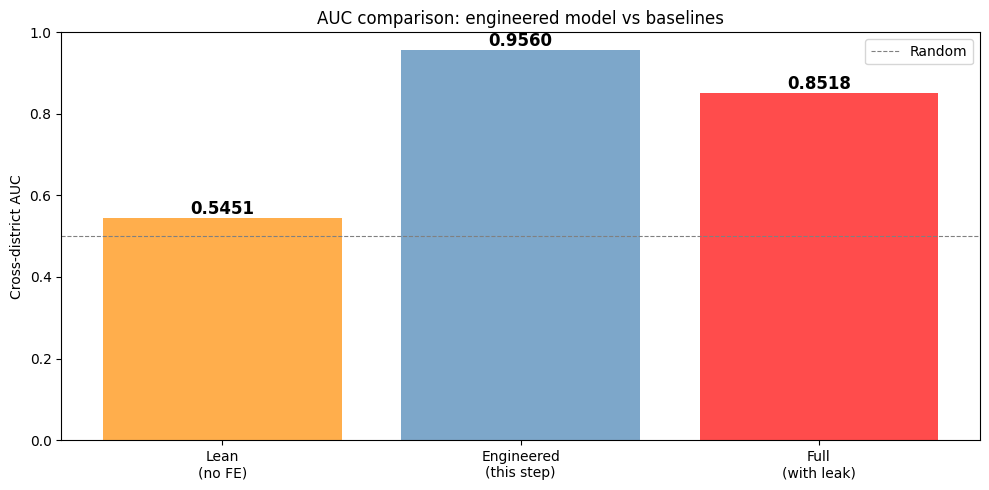

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
variants = ["Lean\n(no FE)", "Engineered\n(this step)", "Full\n(with leak)"]
aucs     = [LEAN_BASELINE_AUC, overall_auc, FULL_BASELINE_AUC]
colors   = ["darkorange", "steelblue", "red"]
bars = ax.bar(variants, aucs, color=colors, alpha=0.7)
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{auc:.4f}", ha="center", fontsize=12, fontweight="bold")
ax.axhline(y=0.5, color="grey", linestyle="--", linewidth=0.8, label="Random")
ax.set_ylabel("Cross-district AUC")
ax.set_title("AUC comparison: engineered model vs baselines")
ax.set_ylim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/auc_comparison.png", dpi=80)
plt.show()
plt.close()

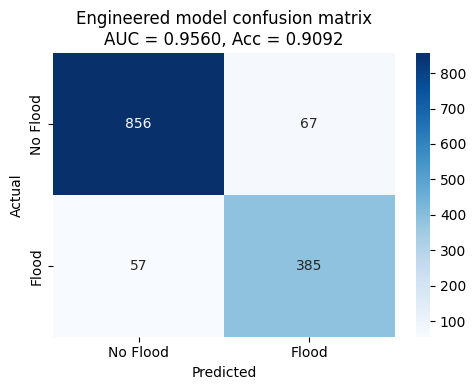

In [17]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Flood", "Flood"], yticklabels=["No Flood", "Flood"])
plt.title(f"Engineered model confusion matrix\nAUC = {overall_auc:.4f}, Acc = {acc:.4f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/confusion_matrix.png", dpi=80)
plt.show()
plt.close()

In [18]:
np.save(f"{MODELS_DIR}/oof_preds_engineered.npy", oof_preds)
importance_df.to_csv(f"{MODELS_DIR}/feature_importance_engineered.csv", index=False)
for i, m in enumerate(models, start=1):
    m.save_model(f"{MODELS_DIR}/lgb_engineered_fold{i}.txt")

print(f"Artifacts saved to {MODELS_DIR}/  and  {PLOTS_DIR}/")

Artifacts saved to engineered_models/  and  engineered_plots/
